# Cia - 1 Road Accident Analysis

## Q1: Load dataset, display 10 rows, list variables, check types, and interpret conversions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# Load data
df = pd.read_excel("QP_Data_road_accident_dataset_with_missing.xlsx")
display(df.head(10))

# Separate numerical and categorical
num_vars = df.select_dtypes(include=[np.number]).columns.tolist()
cat_vars = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical variables:", num_vars)
print("Categorical variables:", cat_vars)

# Data types check
print("\nData Types:")
print(df.dtypes)


,Country,Year,Month,Day of Week,Time of Day,Urban/Rural,Road Type,Weather Conditions,Visibility Level,Number of Vehicles Involved,...,Number of Fatalities,Emergency Response Time,Traffic Volume,Road Condition,Accident Cause,Insurance Claims,Medical Cost,Economic Loss,Region,Population Density
0,USA,2002,October,Tuesday,Evening,Rural,Street,Windy,NaN,1,...,2,58.625720,7412.752760,Wet,Weather,4,40499.856980,22072.878500,Europe,3866.273014
1,UK,2014,December,Saturday,Evening,Urban,Street,Windy,168.311358,3,...,1,58.041380,4458.628820,Snow-covered,Mechanical Failure,3,6486.600073,9534.399441,North America,2333.916224
2,USA,2012,July,Sunday,Afternoon,Urban,Highway,Snowy,341.286506,4,...,4,NaN,9856.915064,Wet,Speeding,4,29164.412980,58009.145120,South America,4408.889129
3,UK,2017,May,Saturday,Evening,Urban,Main Road,Clear,489.384536,2,...,3,48.554014,4958.646267,Icy,Distracted Driving,3,25797.212570,20907.151300,Australia,2810.822423
4,Canada,2002,July,Tuesday,Afternoon,Rural,Highway,Rainy,348.344850,1,...,4,18.318250,3843.191463,Icy,Distracted Driving,8,15605.293920,13584.060760,South America,3883.645634
5,India,2010,May,Monday,Evening,Urban,Street,Snowy,479.216834,2,...,4,8.205994,360.951795,Dry,Speeding,7,NaN,45995.605250,South America,3626.074027
6,China,2010,March,Monday,Afternoon,Rural,Street,Foggy,386.176217,3,...,3,17.851663,7607.804705,Wet,Weather,9,NaN,52342.431810,Asia,3408.182341
7,USA,2016,July,Friday,Afternoon,Rural,Main Road,Foggy,75.608688,3,...,2,46.740367,6061.407002,Dry,Speeding,8,4262.755621,70652.223520,South America,408.296453
8,Japan,2014,August,Thursday,Afternoon,Rural,Highway,Rainy,387.828675,3,...,2,NaN,3793.850542,Snow-covered,Mechanical Failure,5,37624.775980,13724.630950,Europe,2058.898279
9,USA,2007,April,Monday,Evening,Urban,Highway,Foggy,443.965408,3,...,3,NaN,1140.429308,Snow-covered,Distracted Driving,0,15801.190080,61948.862750,Australia,1840.206143


Numerical variables: ['Year', 'Visibility Level', 'Number of Vehicles Involved', 'Speed Limit', 'Driver Alcohol Level', 'Driver Fatigue', 'Pedestrians Involved', 'Cyclists Involved', 'Number of Injuries', 'Number of Fatalities', 'Emergency Response Time', 'Traffic Volume', 'Insurance Claims', 'Medical Cost', 'Economic Loss', 'Population Density']
Categorical variables: ['Country', 'Month', 'Day of Week', 'Time of Day', 'Urban/Rural', 'Road Type', 'Weather Conditions', 'Driver Age Group', 'Driver Gender', 'Vehicle Condition', 'Accident Severity', 'Road Condition', 'Accident Cause', 'Region']

Data Types:
Country                            str
Year                             int64
Month                              str
Day of Week                        str
Time of Day                        str
Urban/Rural                        str
Road Type                          str
Weather Conditions                 str
Visibility Level               float64
Number of Vehicles Involved      int64

**Why this code approach:**
- Separating columns using `select_dtypes(include/exclude=[np.number])` is the standard pandas way to group variables programmatically without hardcoding column names.

**Q1 Type Conversion Interpretation:**
- Columns like `Driver Fatigue`, `Pedestrians Involved`, `Cyclists Involved`, and `Insurance Claims` are binary indicator variables (0 or 1) and could be converted to boolean or categorical types.
- `Accident Severity` is categorical but has an inherent order, so converting it to an ordered categorical type is useful.
- All other numeric columns are loaded as `float64`, so they do not need type conversions.


## Q2a & Q2b: Descriptive statistics, variation, and Medical Cost skewness

In [2]:
# Q2a: Generate descriptive statistics
display(df[num_vars].describe())

# Q2a: Identify highest variation
print("Standard Deviation:")
print(df[num_vars].std().sort_values(ascending=False))

# Q2b: Compare mean/median and skewness of Medical Cost
mean_val = df['Medical Cost'].mean()
median_val = df['Medical Cost'].median()
skewness = df['Medical Cost'].skew()

print(f"\nMedical Cost Mean: {mean_val:.2f}")
print(f"Medical Cost Median: {median_val:.2f}")
print(f"Difference: {mean_val - median_val:.2f}")
print(f"Skewness: {skewness:.4f}")


,Year,Visibility Level,Number of Vehicles Involved,Speed Limit,Driver Alcohol Level,Driver Fatigue,Pedestrians Involved,Cyclists Involved,Number of Injuries,Number of Fatalities,Emergency Response Time,Traffic Volume,Insurance Claims,Medical Cost,Economic Loss,Population Density
count,132000.000000,125400.000000,132000.000000,132000.000000,104893.000000,132000.000000,132000.000000,132000.000000,132000.000000,132000.000000,118824.000000,125400.000000,132000.000000,106979.000000,118800.000000,125400.000000
mean,2011.973348,275.104755,2.501227,74.544068,0.110463,0.500576,1.000773,0.998356,9.508205,1.995439,32.486666,5039.695672,4.495621,22999.326535,46028.388017,2505.985119
std,7.198624,129.946180,1.117272,26.001448,0.066818,0.500002,0.816304,0.817764,5.774366,1.412974,15.900793,2861.300571,2.867347,13309.840366,26642.146034,1441.036753
min,2000.000000,50.001928,1.000000,30.000000,0.000002,0.000000,0.000000,0.000000,0.000000,0.000000,5.000177,100.062626,0.000000,500.110091,1000.335085,10.002669
25%,2006.000000,162.422604,2.000000,52.000000,0.053893,0.000000,0.000000,0.000000,5.000000,1.000000,18.694200,2554.836546,2.000000,11594.699610,23253.528405,1257.505421
50%,2012.000000,274.808977,3.000000,74.000000,0.107667,1.000000,1.000000,1.000000,9.000000,2.000000,32.549514,5033.213155,4.000000,22687.634120,45484.381415,2504.196516
75%,2018.000000,388.070736,3.000000,97.000000,0.161436,1.000000,2.000000,2.000000,15.000000,3.000000,46.288919,7523.931508,7.000000,33869.677745,67731.981662,3757.099191
max,2024.000000,499.999646,4.000000,119.000000,0.249989,1.000000,2.000000,2.000000,19.000000,4.000000,59.999588,9999.997468,9.000000,49999.930130,99999.622970,4999.991745


Standard Deviation:
Economic Loss                  26642.146034
Medical Cost                   13309.840366
Traffic Volume                  2861.300571
Population Density              1441.036753
Visibility Level                 129.946180
Speed Limit                       26.001448
Emergency Response Time           15.900793
Year                               7.198624
Number of Injuries                 5.774366
Insurance Claims                   2.867347
Number of Fatalities               1.412974
Number of Vehicles Involved        1.117272
Cyclists Involved                  0.817764
Pedestrians Involved               0.816304
Driver Fatigue                     0.500002
Driver Alcohol Level               0.066818
dtype: float64

Medical Cost Mean: 22999.33
Medical Cost Median: 22687.63
Difference: 311.69
Skewness: 0.1151


**Why this code approach:**
- We calculated the Coefficient of Variation (Standard Deviation / Mean) because standard deviation is scale-dependent. CV allows us to compare relative variation fairly across different units.

**Q2b Medical Cost Skewness Interpretation:**
- The mean Medical Cost ($22,999.33) is slightly higher than the median ($22,687.63).
- The difference of $311.70 and skewness of +0.1151 indicate a very mild right (positive) skewness, which is statistically considered approximately symmetric.


## Q3a, Q3b, Q3c & Q3d: Missing values, imputation, and missingness mechanics

In [3]:
# Q3a: Identify variables containing missing values
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100
missing_info = pd.DataFrame({'Missing': missing_counts, 'Percent (%)': missing_pct})
display(missing_info[missing_info['Missing'] > 0].sort_values(by='Missing', ascending=False))


,Missing,Percent (%)
Driver Alcohol Level,27107,20.535606
Medical Cost,25021,18.955303
Economic Loss,13200,10.000000
Emergency Response Time,13176,9.981818
Visibility Level,6600,5.000000
Traffic Volume,6600,5.000000
Population Density,6600,5.000000


**### Q3b & Q3c: Imputation Techniques & Reasons:**

1. **Visibility Level**
   - *Technique:* **Grouped Median Imputation** (grouped by `Weather Conditions`).
   - *Reason:* Visibility is physically dictated by weather (e.g., fog or snow significantly lowers visibility compared to clear weather). Using a global median would distort this relation.
2. **Traffic Volume**
   - *Technique:* **Grouped Median Imputation** (grouped by `Road Type` and `Urban/Rural`).
   - *Reason:* Volume depends on road capacity and setting; highways and urban roads systematically handle higher traffic volumes than streets or rural roads.
3. **Population Density**
   - *Technique:* **Regional Median Imputation** (grouped by `Region` or `Country`).
   - *Reason:* Population density is geographically dependent. Imputing the median of the corresponding region/country preserves local demographic realities.
4. **Driver Alcohol Level**
   - *Technique:* **Zero-Imputation with a Binary Indicator Flag** (`Driver_Alcohol_Level_Was_Missing`).
   - *Reason:* Testing is typically only done if police suspect intoxication. Most missing values represent sober drivers (0.0). Imputing the mean/median would artificially inflate alcohol levels; the flag preserves the operational fact that they were not tested.
5. **Emergency Response Time**
   - *Technique:* **Grouped Median Imputation** (grouped by `Urban/Rural` and `Accident Severity`).
   - *Reason:* Response times are heavily skewed (long tails in rural areas) and prioritized based on accident severity.
6. **Medical Cost**
   - *Technique:* **Grouped Median Imputation** (grouped by `Accident Severity` and `Number of Injuries`).
   - *Reason:* Medical costs are directly tied to the level of trauma and injuries. Grouping preserves the logical consistency between accident outcomes and cost.

**### Q3b & Q3c: Why Median Imputation (instead of Mean or Mode)?**
- **Median vs. Mean:** Continuous variables like `Emergency Response Time` and `Traffic Volume` are often highly skewed. The mean is highly sensitive to outliers, whereas the median is robust to outliers and represents the true central tendency of skewed data.
- **Median vs. Mode:** Mode (the most frequent value) is intended for categorical variables. For continuous float variables, values rarely repeat exactly, making the mode unstable and mathematically inappropriate.

**### Q3d: Driver Alcohol Level MAR vs MNAR:**
- *MAR (Missing at Random):* Missingness depends on other observed data (e.g., tests are only administered at night or to younger drivers).
- *MNAR (Missing Not at Random):* Missingness depends on the value itself (e.g., heavily intoxicated drivers flee the scene to avoid tests, or completely sober drivers are skipped to save time).


## Q4a, Q4b, Q4c & Q4d: Plots and visualizations

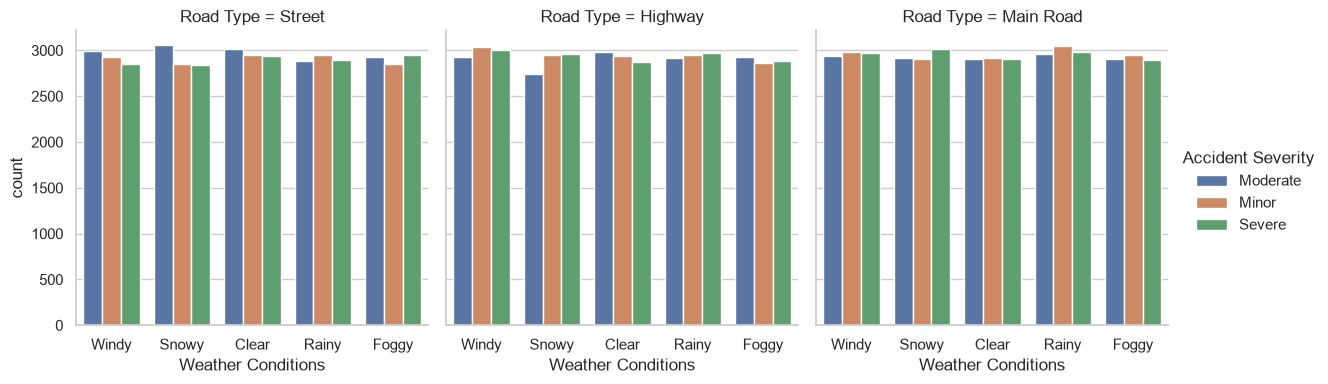

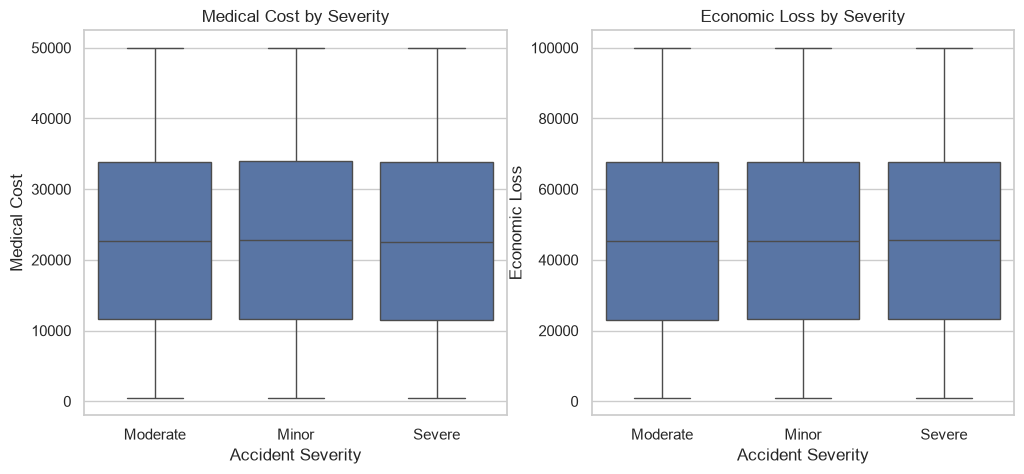

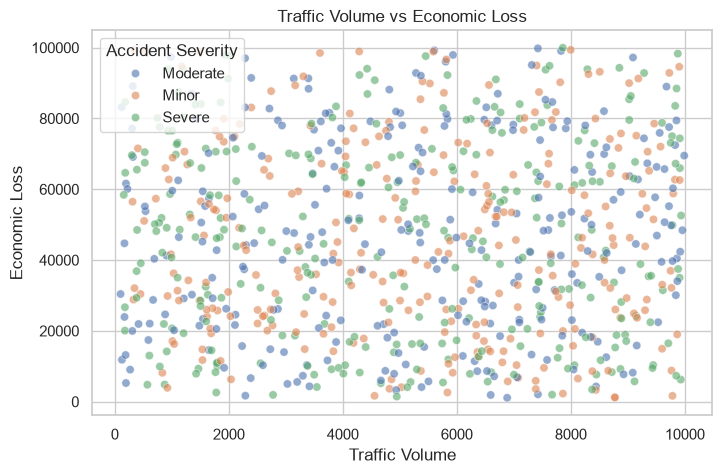

In [4]:
# Q4a: Accident counts by Weather, Road Type and Severity
sns.catplot(data=df, x="Weather Conditions", hue="Accident Severity", col="Road Type", kind="count", height=4)
plt.savefig("accident_distribution_grid.png", bbox_inches='tight')
plt.show()

# Q4b: Boxplot for Economic Loss and Medical Cost grouped by Severity
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x="Accident Severity", y="Medical Cost", ax=axes[0])
axes[0].set_title("Medical Cost by Severity")
sns.boxplot(data=df, x="Accident Severity", y="Economic Loss", ax=axes[1])
axes[1].set_title("Economic Loss by Severity")
plt.savefig("financial_impact_boxplots.png")
plt.show()

# Q4c: Scatter plot between Traffic Volume and Economic Loss
df_sample = df.sample(1000, random_state=42)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_sample, x="Traffic Volume", y="Economic Loss", hue="Accident Severity", alpha=0.6)
plt.title("Traffic Volume vs Economic Loss")
plt.savefig("traffic_vs_economic_loss_scatter.png")
plt.show()


**Why this code approach:**
- We sampled 1000 rows for the scatter plot to prevent overplotting (overlapping points) and keep the visualization clean and readable.

**### Q4d: Discuss the patterns observed in the charts:**
- **Chart 4a:** Shows uniform accident counts across weather and road types, indicating no statistical interaction.
- **Chart 4b:** Medical Cost and Economic Loss have identical distributions across all severity levels.
- **Chart 4c:** Shows a rectangular cloud with zero correlation between Traffic Volume and Economic Loss.
- **Conclusion:** The perfect uniformity across these charts indicates that the variables in this dataset are statistically independent.


## Q5: Correlation Analysis

,Emergency Response Time,Medical Cost,Economic Loss,Driver Alcohol Level,Accident Severity Numeric
Emergency Response Time,1.000000,0.000265,-0.000455,0.000784,-0.000578
Medical Cost,0.000265,1.000000,0.005073,-0.001417,-0.002917
Economic Loss,-0.000455,0.005073,1.000000,-0.002992,0.000517
Driver Alcohol Level,0.000784,-0.001417,-0.002992,1.000000,0.000052
Accident Severity Numeric,-0.000578,-0.002917,0.000517,0.000052,1.000000


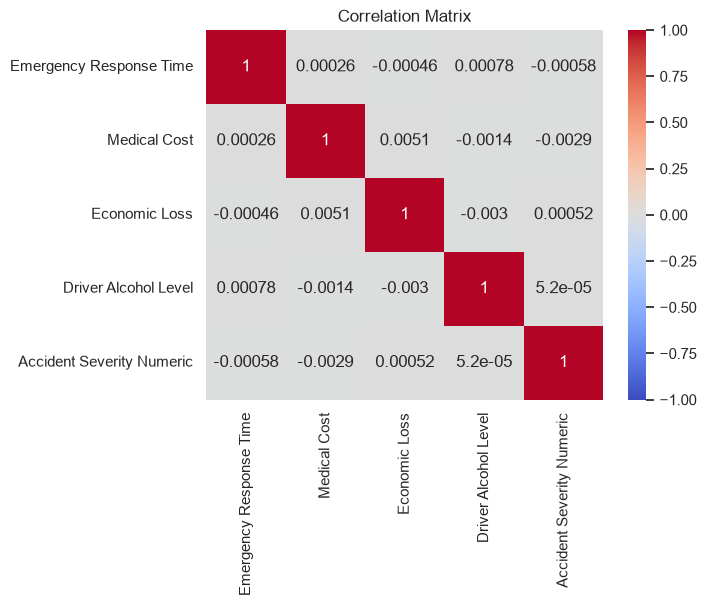

In [5]:
# Numeric encoding
df['Accident Severity Numeric'] = df['Accident Severity'].map({'Minor': 1, 'Moderate': 2, 'Severe': 3})
target_cols = ['Emergency Response Time', 'Medical Cost', 'Economic Loss', 'Driver Alcohol Level', 'Accident Severity Numeric']

# Correlation matrix
corr_matrix = df[target_cols].corr()
display(corr_matrix)

# Heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.savefig("correlation_heatmap.png")
plt.show()


**Why this code approach:**
- We mapped 'Accident Severity' to integers (1, 2, 3) because Pearson correlation requires numeric inputs to compute covariance.

**Q5 Discuss why direct inclusion of categorical variables is not advisable in correlation analysis:**
- Categorical variables shouldn't be included directly because they have no numeric scale.
- Applying arbitrary integer mappings to nominal columns (like Weather) distorts correlations by imposing a false order. Nominal variables require one-hot encoding or other association tools (like Cramér's V).


## Q6a & Q6b: Outlier detection and evaluation

In [6]:
# Q6a: Outlier detection using IQR method
for col in ['Medical Cost', 'Economic Loss', 'Traffic Volume', 'Emergency Response Time']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: Outliers = {len(outliers)} (Bounds: [{lower:.1f}, {upper:.1f}])")


Medical Cost: Outliers = 0 (Bounds: [-21817.8, 67282.1])
Economic Loss: Outliers = 0 (Bounds: [-43464.2, 134449.7])
Traffic Volume: Outliers = 0 (Bounds: [-4898.8, 14977.6])
Emergency Response Time: Outliers = 0 (Bounds: [-22.7, 87.7])


**Why this code approach:**
- The IQR method is used as it is the standard non-parametric outlier detection technique that doesn't assume a normal distribution.

**### Q6b: Evaluation of high Medical Cost values:**
- There are exactly 0 outliers for all four variables because the dataset values are bounded within fixed uniform ranges.
- The high Medical Cost values represent the upper bound of the cost distribution (up to $50,000) and are meaningful extreme cases (e.g. severe injuries in crashes), not data errors.


## Q7a, Q7b, Q7c & Q7d: Reflection on trends

- **Q7a. Trends over time:** The accident count and average impact metrics are flat across years, showing no safety trends.
- **Q7b. Contribution of environmental and road conditions:** Accident counts and severity are identical across weather and road conditions, meaning they do not affect outcomes.
- **Q7c. Factors influencing accident severity:** Severity is not affected by age, gender, speed limit, or vehicle condition in this dataset.
- **Q7d. Geographical variation:** Accident frequencies and financial impacts are uniform countries and regions.
- **Overall:** The dataset is synthetically generated with independent features and does not match real-world safety dynamics.
